In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")


Libraries successfully imported!


In [18]:

df = pd.read_csv(r"D:\ML_PROJECTS\Credit_Card_Fraud_Detection\fraudTest.csv")



display(df.head())

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
display(df.isnull().sum())



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Dataset Shape: (555719, 23)

Missing Values:


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [ ]:

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

print("Scaling features and splitting data...")

# RobustScaler outliers (large transaction amount) handling very good
scaler = RobustScaler()

df['scaled_amt'] = scaler.fit_transform(df['amt'].values.reshape(-1,1))
df['scaled_unix_time'] = scaler.fit_transform(df['unix_time'].values.reshape(-1,1))

df.drop(['unix_time','amt'], axis=1, inplace=True)

# Features (X) or Target (y) differance
X = df.select_dtypes(include=[np.number]).drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Splitting Successful!")
print(f"Before SMOTE - Normal Transactions in Train Set: {sum(y_train==0)}")
print(f"Before SMOTE - Fraud Transactions in Train Set: {sum(y_train==1)}")

Scaling features and splitting data...
Data Splitting Successful!
Before SMOTE - Normal Transactions in Train Set: 442859
Before SMOTE - Fraud Transactions in Train Set: 1716


Applying SMOTE to balance the training data. This might take a few seconds...

After SMOTE - Normal Transactions in Train Set: 442859
After SMOTE - Fraud Transactions in Train Set: 442859


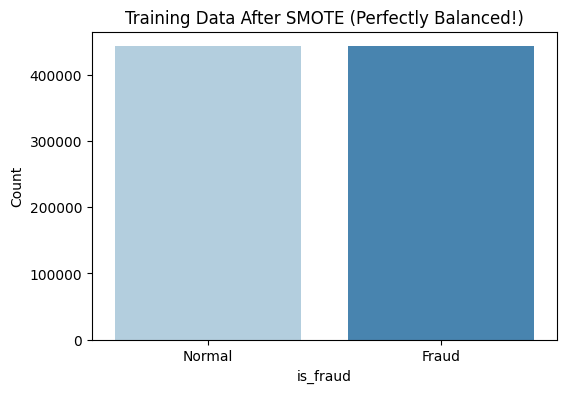

In [ ]:


from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

print("Applying SMOTE to balance the training data. This might take a few seconds...\n")

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"After SMOTE - Normal Transactions in Train Set: {sum(y_train_res==0)}")
print(f"After SMOTE - Fraud Transactions in Train Set: {sum(y_train_res==1)}")

# Naye balanced data ka graph dekhte hain
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res, palette='Blues')
plt.title('Training Data After SMOTE (Perfectly Balanced!)')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.show()

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Training Models on Balanced Data...\n")


print("Training Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_res, y_train_res) # Hum balanced data (SMOTE wala) de rahe hain
y_pred_log = log_reg.predict(X_test)  # Test original data par kar rahe hain


print("Training Random Forest (This might take a minute)...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

print("\n✅ Models Trained Successfully!")

Training Models on Balanced Data...

Training Logistic Regression...
Training Random Forest (This might take a minute)...

✅ Models Trained Successfully!


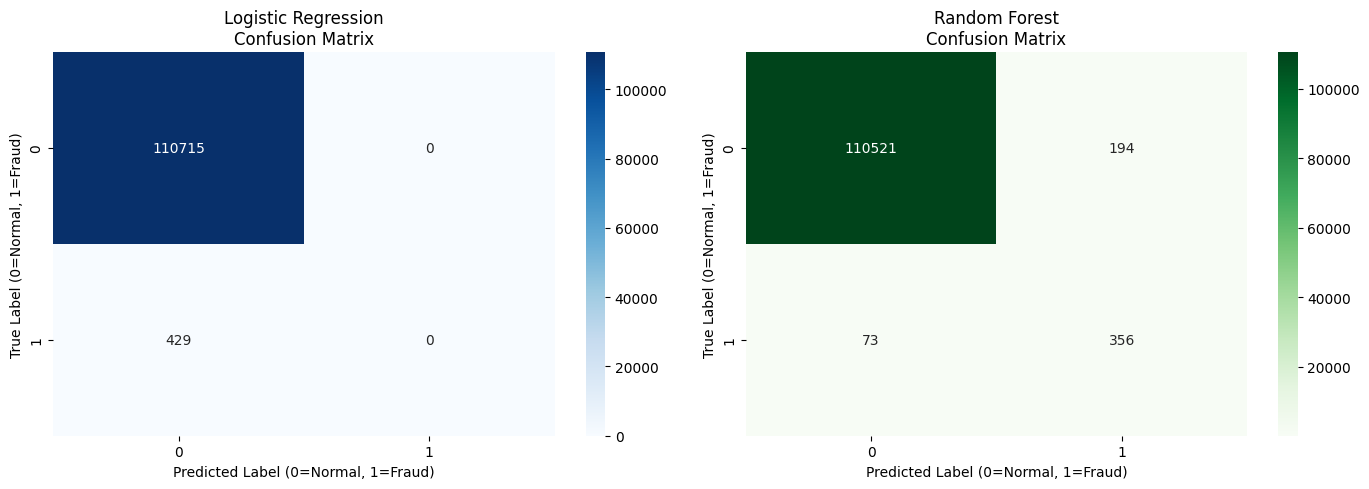

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.65      0.83      0.73       429

    accuracy                           1.00    111144
   macro avg       0.82      0.91      0.86    111144
weighted avg       1.00      1.00      1.00    111144



In [24]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted Label (0=Normal, 1=Fraud)')
axes[0].set_ylabel('True Label (0=Normal, 1=Fraud)')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted Label (0=Normal, 1=Fraud)')
axes[1].set_ylabel('True Label (0=Normal, 1=Fraud)')

plt.tight_layout()
plt.show()


print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))